# Deep learning applied to gravitational lensing

## Import parameters

In [1]:
import pandas as pd

df = pd.read_csv("mock_lenses_hsc.csv")
df

,objID,objID_src,rot,x_lens,y_lens,q,PA,r_Einstein,z_source,z_lens,velDisp,x_source,y_source,boost,shear,shear_PA
0,1,1090,0,0.038127,-0.083938,0.832873,1.099377,2.454128,3.127611,0.730786,378.07416,-0.279477,-0.477602,-1.0,0.022431,0.911779
1,2,426,0,-0.082791,-0.109870,0.742644,1.852767,2.468242,5.798559,0.441585,329.32822,-0.074636,-0.380427,-3.0,0.059983,0.958381
2,3,2136,0,-0.054644,-0.008364,0.845785,2.936826,2.475322,4.785457,0.454826,333.96304,-0.133183,-0.277230,-3.0,0.038890,1.134869
3,4,7141,0,-0.030885,-0.070501,0.857919,2.483655,2.456651,4.792636,0.819645,369.14502,-0.133090,-0.034229,-4.0,0.005173,2.657499
4,5,7215,0,-0.038541,0.001391,0.899268,0.382301,2.497800,4.860585,0.703609,359.74615,-0.318418,-0.027564,-4.0,0.043490,1.112804
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43728,51996,1083,1,0.012901,-0.058693,0.867499,1.836198,0.776824,0.827810,0.415259,248.21088,0.057228,-0.057947,-4.0,0.054220,2.249565
43729,51997,12,2,-0.001551,0.024924,0.808340,2.464540,0.756855,0.996663,0.422812,228.52315,-0.070151,-0.063773,-3.0,0.029062,2.235106
43730,51998,11,0,0.006303,-0.002664,0.750802,2.697964,0.792795,1.037593,0.484768,245.66832,-0.018803,-0.008539,-1.0,0.045575,2.531362
43731,51999,1273,0,0.046707,0.056492,0.853459,1.348237,0.786784,2.172062,0.494431,204.68020,0.006797,-0.021310,-1.0,0.041806,2.955045


## Ellipticity

Compute $e_x$ and $e_y$

where :
$$e_x = \text{cos}(2\theta)\frac{1-q^2}{1+q^2} \quad \text{and} \quad e_y = \text{sin}(2\theta)\frac{1-q^2}{1+q^2}$$

and :
$$q = \frac{\sqrt{1 - \sqrt{e_x^2 + e_y^2}}}{\sqrt{1 + \sqrt{e_x^2 + e_y^2}}}$$


In [2]:
import numpy as np
df['ex'] = np.cos(2 * df.PA) * (1 - df.q**2)/(1 + df.q**2)
df['ey'] = np.sin(2 * df.PA) * (1 - df.q**2)/(1 + df.q**2)

In [3]:
df['qq'] = np.sqrt((1 - np.sqrt(df.ex **2 + df.ey**2)) / (1 + np.sqrt(df.ex **2 + df.ey**2)) )
df['diff'] = df.q - df.qq

## Shear

Compute $\gamma_{ext,1}$ and $\gamma_{ext,2}$
where:
$$\gamma_{ext, 1} = \text{cos}(2\theta) \ \gamma_{ext} \quad \text{and} \quad \gamma_{ext, 2} = \text{sin}(2\theta) \ \gamma_{ext}$$
and :
$$\gamma_{ext} = \sqrt{\gamma_{ext, 1}^2 + \gamma_{ext,2}^2}$$

In [4]:
df['gamma1'] = np.cos(2 * df.shear_PA) * df.shear
df['gamma2'] = np.sin(2 * df.shear_PA) * df.shear

## Distribution of the dataset

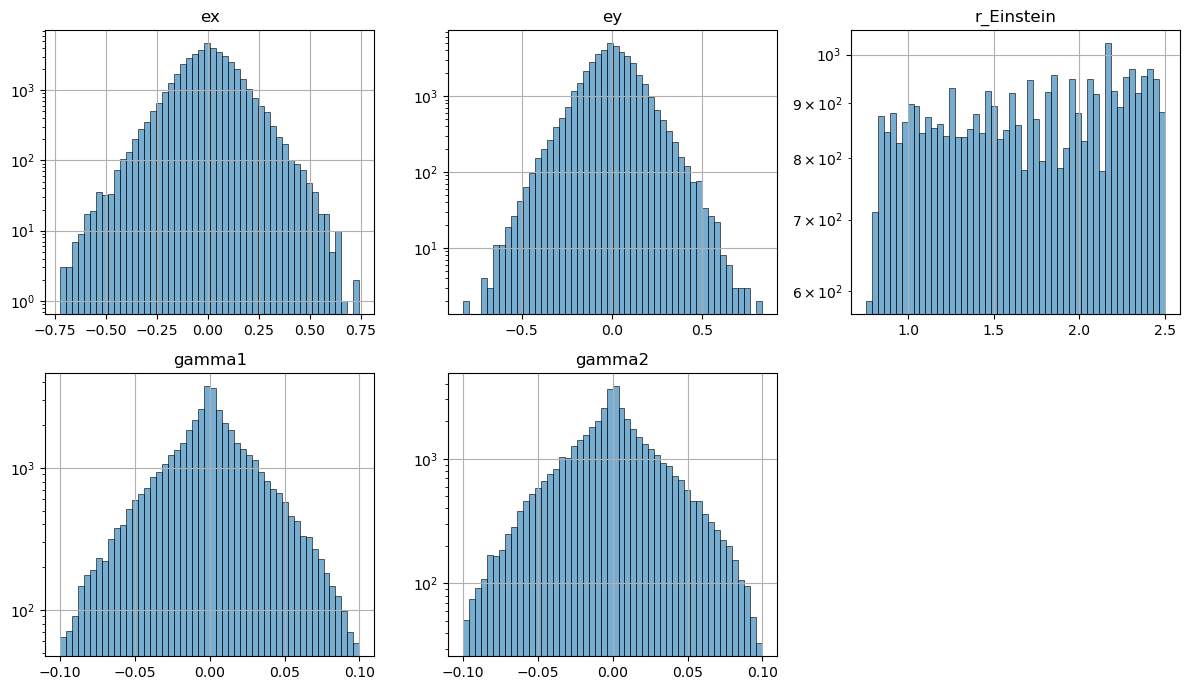

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
axes = axes.flatten()   
columns = ["ex", "ey", "r_Einstein", "gamma1", "gamma2"]

for i, col in enumerate(columns):
    axes[i].hist(df[col], bins=50, alpha=0.6, log=True, edgecolor='black',linewidth=0.7)
    axes[i].set_title(col)
    axes[i].grid(True)

# axes[-2].axis("off")
axes[-1].axis("off")

plt.tight_layout()
plt.savefig("/net/CLUSTER/VAULT/users/mbatt/gravitational_lensing/plots/Dataset_histograms.png", dpi=300, bbox_inches="tight")
plt.show()

## Images

In [6]:
import os
os.chdir("/home/rcanameras/data/mock_lenses_hsc/")
# os.chdir("/home/mbatt")

In [7]:
folders = [f for f in os.listdir() if 'csv' not in f]

dict_im = {}
for fold in folders: 
    for file in os.listdir(fold):
        if '.fits' in file:
            objID = int(file.split('_')[1])
            dict_im[objID] = [fold + "/" + file]

In [8]:
df_im = pd.DataFrame(dict_im).T
df_im = df_im.reset_index()
df_im.columns = ["objID", "location"]

In [9]:
df_full = df.merge(df_im, on = "objID", how = 'left')

In [10]:
df_sample = df_full#.sample(n=2000, random_state=42)

In [11]:
import os
os.chdir("/home/mbatt")

In [12]:
image_index = 9

## Images raw

Opening: /home/rcanameras/data/mock_lenses_hsc/final_hscsearch_2e3_1/lens_12_source_1225_r_0.fits


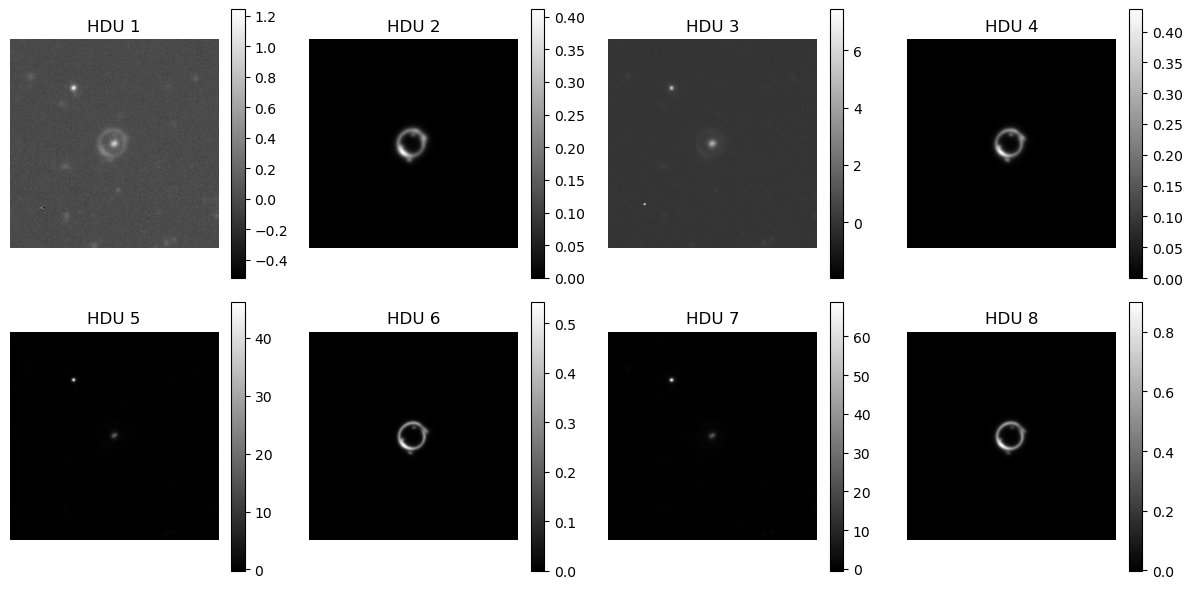

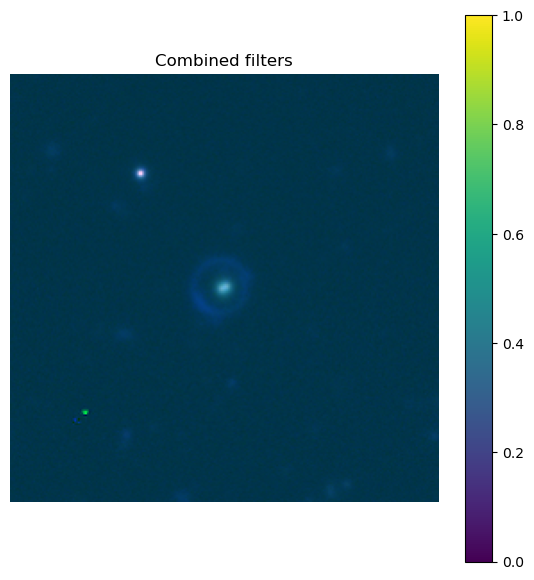

In [13]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
import os
import random
import torch

folder = "/home/rcanameras/data/mock_lenses_hsc"
file = os.path.join(folder, df_sample.location.values[image_index])
print("Opening:", file)

with fits.open(file) as hdul:
    images = [hdul[i].data for i in range(1, len(hdul))]
    
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for ax, img, idx in zip(axes.ravel(), images, range(1, len(images)+1)):
    im = ax.imshow(img, origin='lower', cmap='gray')
    fig.colorbar(im, ax=ax)
    ax.set_title(f"HDU {idx}")
    ax.axis('off')

plt.tight_layout()
plt.show()

with fits.open(file) as hdul:
    g = hdul[1].data
    r = hdul[3].data
    i = hdul[5].data
    z = hdul[7].data
    
R, G, B = i, r, g

def norm(x):
    x = x - np.nanmin(x)
    x = x / np.nanmax(x)
    return x

Rn, Gn, Bn = norm(R), norm(G), norm(B)

rgb = np.dstack([Rn, Gn, Bn])

plt.figure(figsize=(6,6))
plt.imshow(rgb, origin='lower')
plt.tight_layout()
plt.axis('off')
plt.title("Combined filters")
plt.colorbar()
plt.show()

In [14]:
import torch
from astropy.io import fits
import numpy as np

def save_fits_as_tensor(arr, save_path):
    # arr is dimension 8
    tensor = torch.tensor(arr, dtype=torch.float32)
    torch.save(tensor, save_path)

In [15]:
path_image = "/net/CLUSTER/VAULT/users/rcanameras/data/mock_lenses_hsc/"
save_path = "/net/CLUSTER/VAULT/users/mbatt/data/"

In [16]:
# import random
# from tqdm import tqdm
# import os

# w1, w2 = 8, 232 # image will be of dimension w2-w1 x w2-w1
# LL = [f for f in os.listdir(save_path)]

# for ima_file in tqdm(df_sample.location):
# #     if ima_file.split('/')[1] + '.pt' not in LL:
#     with fits.open(path_image + ima_file) as hdul:
#         c = random.randint(0, w1)
#         images = [hdul[i].data[w1+c:w2+c,w1+c:w2+c] for i in range(1, len(hdul))]
#         arr = np.stack(images, axis=0)
#         save_fits_as_tensor(arr, save_path + ima_file.split('/')[1] + ".pt")

## Images reformated

Found FITS: 43734
Opening: /net/CLUSTER/VAULT/users/mbatt/data/lens_12_source_1225_r_0.fits.pt


/tmp/ipykernel_55576/4083360855.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  images = torch.load(file)[::2]


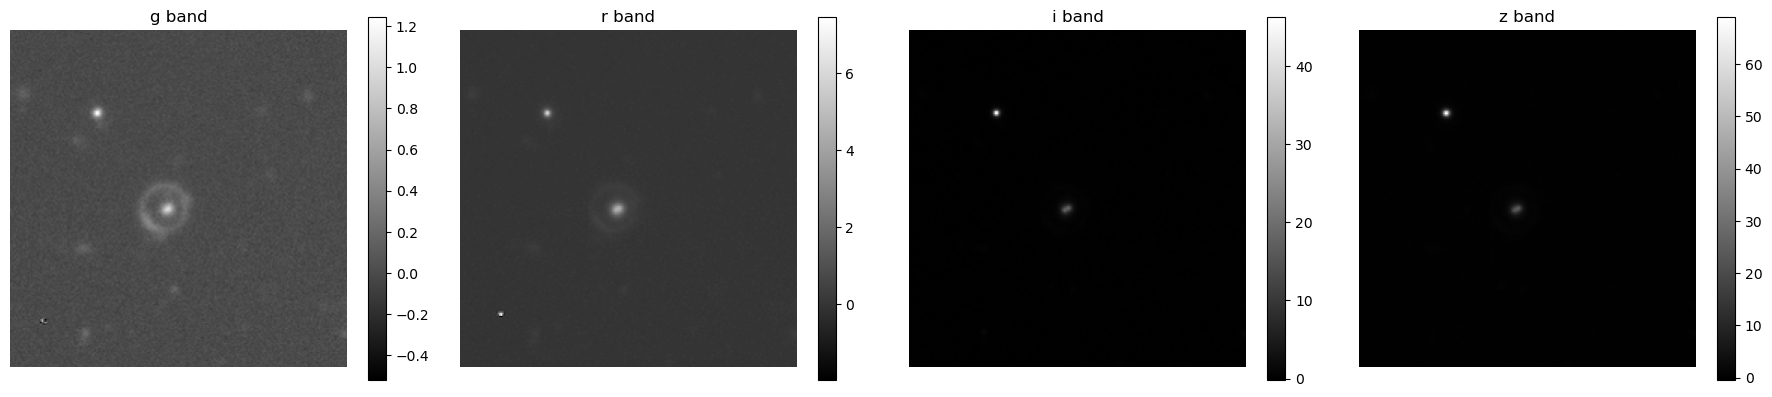

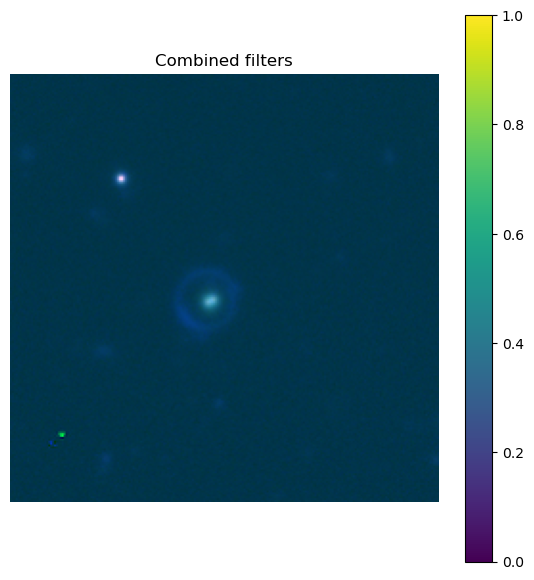

In [17]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
import os
import random

folder =  "/net/CLUSTER/VAULT/users/mbatt/data/"
fits_files = [f for f in os.listdir(folder)]
print("Found FITS:", len(fits_files))

file = os.path.join(folder, df_sample.location.values[image_index].split("/")[1] + ".pt")
images = torch.load(file)[::2]
print("Opening:", file)

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

bandes = ['g', 'r', 'i', 'z']
for ax, img, idx in zip(axes.ravel(), images, range(1, len(images)+1)):
    im = ax.imshow(img, origin='lower', cmap='gray')
    fig.colorbar(im, ax=ax)
    ax.set_title(f"{bandes[idx-1]} band")
    ax.axis('off')

plt.tight_layout()
plt.show()

g = images[0]
r = images[1]
i = images[2]
z = images[3]
    
R, G, B = i, r, g

def norm(x):
    x = x - np.nanmin(x)
    x = x / np.nanmax(x)
    return x

Rn, Gn, Bn = norm(R), norm(G), norm(B)

rgb = np.dstack([Rn, Gn, Bn])

plt.figure(figsize=(6,6))
plt.imshow(rgb, origin='lower')
plt.tight_layout()
plt.axis('off')
plt.title("Combined filters")
plt.colorbar()
plt.show()

# Deep learning models

In [18]:
dff = df_sample[['r_Einstein', 'gamma1', 'gamma2', 'ex', 'ey', 'location']]
dff = dff.set_index("location")

# Normalization of the parameters

In [19]:
cols_to_norm = ['r_Einstein', 'gamma1', 'gamma2', 'ex', 'ey']
dff[cols_to_norm] = (dff[cols_to_norm] - dff[cols_to_norm].min()) / (dff[cols_to_norm].max() - dff[cols_to_norm].min())

In [20]:
dff = dff.sample(frac=1, random_state=42)

In [21]:
dff.to_csv('/home/mbatt/gravitational_lensing/ready_data.csv')

In [22]:
import pandas as pd
dff = pd.read_csv('/home/mbatt/gravitational_lensing/ready_data.csv', index_col = 0)

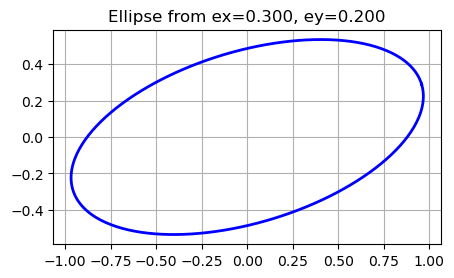

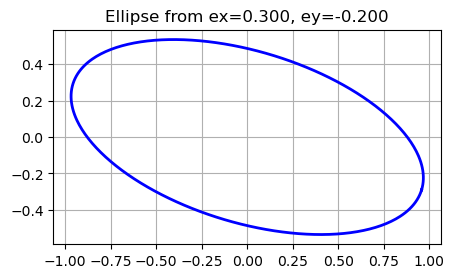

In [23]:
import numpy as np
import matplotlib.pyplot as plt

def plot_ellipse_from_ellipticity(ex, ey, ax=None, scale=1.0):
    # Compute ellipticity magnitude
    e = np.sqrt(ex**2 + ey**2)
    if e >= 1:
        raise ValueError("Ellipticity must satisfy |e| < 1")

    # Orientation angle
    theta = 0.5 * np.arctan2(ey, ex)

    # Axis ratio
    q = (1 - e) / (1 + e)

    # Semi-major and semi-minor axes
    a = scale
    b = q * scale

    # Parametric ellipse
    t = np.linspace(0, 2*np.pi, 400)
    x = a * np.cos(t)
    y = b * np.sin(t)

    # Rotation matrix
    R = np.array([[np.cos(theta), -np.sin(theta)],
                  [np.sin(theta),  np.cos(theta)]])

    xy = R @ np.vstack([x, y])

    # Plot
    if ax is None:
        fig, ax = plt.subplots(figsize=(5,5))

    ax.plot(xy[0], xy[1], 'b', lw=2)
    ax.set_aspect('equal')
    ax.set_title(f"Ellipse from ex={ex:.3f}, ey={ey:.3f}")
    ax.grid(True)

    return ax

# Example
plot_ellipse_from_ellipticity(ex=0.3, ey=0.2)
plt.show()
plot_ellipse_from_ellipticity(ex=0.3, ey=-0.2)
plt.show()


In [24]:
import torch
import torchvision.transforms.functional as TF
import random
def augment_batch(xb, yb):
    L = []
    # Horizontal flip
    if random.random() < 0.5:
        xb = TF.hflip(xb)
        yb[2] = -yb[2]   # gamma1
        yb[4] = -yb[4]   # ey
        print("Horizontal flip")
        L.append('Horizontal')
    # Vertical flip
    if random.random() < 0.5:
        xb = TF.vflip(xb)
        yb[2] = -yb[2]   # gamma2
        yb[4] = -yb[4]   # ey
        print("Vertical flip")
        L.append('Vertical')
    # Small rotation
    angle = random.uniform(-15, 15)
    print("Angle :", angle)
    L.append(angle)
    xb = TF.rotate(xb, angle)
    theta = torch.tensor(angle * torch.pi / 180.0,
                         device=yb.device)
    c = torch.cos(2 * theta)
    s = torch.sin(2 * theta)
    ex = yb[3].clone()
    ey = yb[4].clone()
    yb[3] = ex * c - ey * s
    yb[4] = ex * s + ey * c
    g1 = yb[1].clone()
    g2 = yb[2].clone()
    yb[1] = g1 * c - g2 * s
    yb[2] = g1 * s + g2 * c
    return xb, yb, L

/tmp/ipykernel_55576/1625391374.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  images = torch.load(file)[::2]


Horizontal flip
Vertical flip
Angle : 5.281230252112799


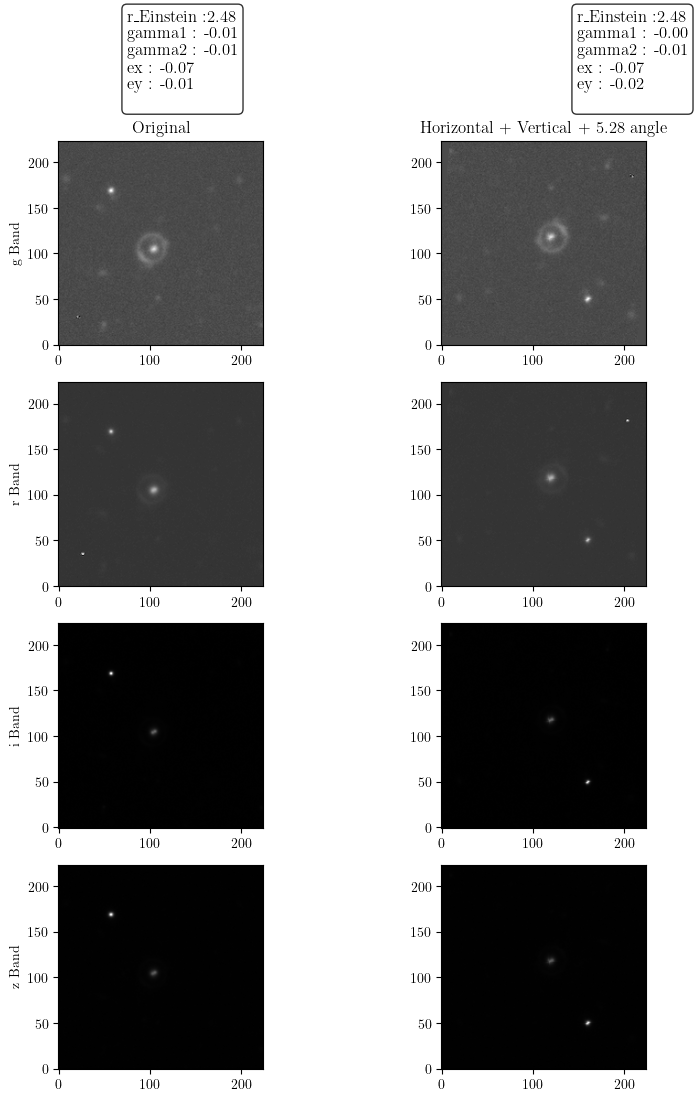

In [25]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
import os
import random
import copy

plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Computer Modern Roman"]

folder =  "/net/CLUSTER/VAULT/users/mbatt/data/"

file = os.path.join(folder, df_sample.location.values[image_index].split("/")[1] + ".pt")
images = torch.load(file)[::2]
Y = torch.from_numpy(df_sample[df_sample.index == image_index][['r_Einstein', 'gamma1', 'gamma2', 'ex', 'ey']].values[0])
y_2 = copy.deepcopy(Y)
img_2, y_2, actions = augment_batch(images, y_2)
# print("Opening:", file)

fig, axes = plt.subplots(4, 2, figsize=(9, 10))

bandes = ['g', 'r', 'i', 'z']
for k in range(4):
    axes[k,0].imshow(images[k], origin='lower', cmap='gray')
    axes[k,1].imshow(img_2[k], origin='lower', cmap='gray')
    # axes[k,0].axis('off')
    # axes[k,1].axis('off')
    axes[k,0].set_ylabel(f'{bandes[k]} Band')

axes[0,0].set_title('Original')
axes[0,1].set_title(" + ".join(str(w) for w in actions[:-1]) + f' + {actions[-1]:.2f} angle')

plt.tight_layout()


plt.text(
    0.25, 1,                     # x, y position in AXIS coordinates (0–1)
    (f'r_Einstein :{Y[0]:.2f}\n'
        f'gamma1 : {Y[1]:.2f}\n'
     f'gamma2 : {Y[2]:.2f}\n'
f'ex : {Y[3]:.2f}\n'
f'ey : {Y[4]:.2f}\n'
    ),   # text
    transform=fig.transFigure,
    fontsize=12,
    color="black",
    bbox=dict(
        facecolor="white",
        edgecolor="black",
        boxstyle="round,pad=0.3",
        alpha=0.8
    )
)
plt.text(
    0.75, 1,                     # x, y position in AXIS coordinates (0–1)
        (f'r_Einstein :{y_2[0]:.2f}\n'
        f'gamma1 : {y_2[1]:.2f}\n'
     f'gamma2 : {y_2[2]:.2f}\n'
f'ex : {y_2[3]:.2f}\n'
f'ey : {y_2[4]:.2f}\n'
    ),   # text,   # text
    transform=fig.transFigure,
    fontsize=12,
    color="black",
    bbox=dict(
        facecolor="white",
        edgecolor="black",
        boxstyle="round,pad=0.3",
        alpha=0.8
    )
)
plt.show()

## Load data

In [26]:
import os
os.chdir('/home/mbatt/gravitational_lensing')

In [27]:
!pwd

/net/CLUSTER/VAULT/users/mbatt/gravitational_lensing


In [28]:
from deep_learning_models import *
from deep_learning_models import LensDataset

In [29]:
import torch
from torch.utils.data import random_split

path_tensor = "/home/mbatt/data"
full_dataset = LensDataset(dff, path_tensor)

train_loader, val_loader, test_loader = full_dataset.split_data(training_pct = 0.6, # 60% for training
                                                                test_pct = 0.2, # 20% for test
                                                                batch_size = 32)

## Import Models

In [ ]:
dinov2_vitb14 = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14')

In [31]:
!conda env list


# conda environments:
#
dinov2                   /home/mbatt/.conda/envs/dinov2
py_3_9_env               /home/mbatt/.conda/envs/py_3_9_env
base                  *  /usr/local/miniconda3
concerto                 /usr/local/miniconda3/envs/concerto



In [32]:
import torch
import torch.nn as nn

class LensingRegressor(nn.Module):
    def __init__(self, dinov2):
        super().__init__()
        
        # 4-band → 3-band adapter
        self.adapter = nn.Conv2d(4, 3, kernel_size=1)
        
        # Pretrained DINOv2 backbone
        self.backbone = dinov2

        for name, p in self.backbone.named_parameters():
            if "blocks.0" in name:# or "blocks.1" in name:
                p.requires_grad = True
            else:
                p.requires_grad = False
        
        # # Freeze backbone at first
        # for p in self.backbone.parameters():
        #     p.requires_grad = False
        
        # Regression head (DINOv2 ViT-B/14 outputs 768-dim CLS token)
        self.head = nn.Sequential(
            nn.Linear(768, 256),
            nn.ReLU(),
            nn.Linear(256, 5)  # 3 outputs: R_E, ellipticity, shear
        )

    def forward(self, x):
        # x = self.adapter(x)
        feats = self.backbone(x)  # CLS embedding
        return self.head(feats)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = LensingRegressor(dinov2_vitb14).to(device)

In [33]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Total parameters: 86,778,644
Trainable parameters: 7,287,572


In [34]:
import torch
print(torch.cuda.is_available())


True


In [35]:
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def weighted_mse(pred, target, weights):
    loss = F.mse_loss(pred, target, reduction='none')
    loss = loss * weights
    return loss.mean()           

weights = torch.tensor([1, 1, 1, 1, 1], device=device)

In [36]:
from process_training import Trainer
import warnings
warnings.filterwarnings("ignore")

In [37]:
import torch
import torch.nn as nn
import torch.optim as optim
import math
from torch.optim.lr_scheduler import ReduceLROnPlateau


patience = 25
early_stop_counter = 0

seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


train_losses = []
val_losses = []

best_val_loss = float('inf')
best_weights = None
# optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-3)
# scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=10)
# scheduler = torch.optim.lr_scheduler.StepLR(
#             optimizer, step_size=10, gamma=0.5)
# scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer,T_max=100)

best_val_loss = float('inf')
best_weights = None

In [38]:
optimizer = torch.optim.AdamW(
    [
        {
            "params": model.head.parameters(),
            "lr": 1e-3,          # strong LR for new head
            "weight_decay": 1e-3,
        },
        {
            "params": [
                p for n, p in model.backbone.named_parameters()
                if p.requires_grad
            ],
            "lr": 1e-5,          # VERY low LR for pretrained layers
            "weight_decay": 1e-3,
        },
    ]
)

scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=10,
    gamma=0.5,
)

In [36]:
# import torch
# from torch.optim.lr_scheduler import SequentialLR, LinearLR, CosineAnnealingLR

# optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

# warmup_epochs = 10
# total_epochs = 60

# warmup_scheduler = LinearLR(
#     optimizer,
#     start_factor=0.1,
#     total_iters=warmup_epochs
# )

# cosine_scheduler = CosineAnnealingLR(
#     optimizer,
#     T_max=total_epochs - warmup_epochs
# )

# scheduler = SequentialLR(
#     optimizer,
#     schedulers=[warmup_scheduler, cosine_scheduler],
#     milestones=[warmup_epochs]
# )

In [37]:
import torch
import torchvision.transforms.functional as TF
import random
def augment_batch(xb, yb):
    B = xb.shape[0]
    for i in range(B):
        # Horizontal flip
        if random.random() < 0.5:
            xb[i] = TF.hflip(xb[i])
            yb[i, 1] = -yb[i, 1]   # ex
            yb[i, 3] = -yb[i, 3]   # gamma1
        # Vertical flip
        if random.random() < 0.5:
            xb[i] = TF.vflip(xb[i])
            yb[i, 2] = -yb[i, 2]   # ey
            yb[i, 3] = -yb[i, 3]   # gamma1
        # Small rotation
        angle = random.uniform(-15, 15)
        xb[i] = TF.rotate(xb[i], angle)
        theta = torch.tensor(angle * torch.pi / 180.0,
                             device=yb.device)
        c = torch.cos(2 * theta)
        s = torch.sin(2 * theta)
        ex = yb[i, 1].clone()
        ey = yb[i, 2].clone()
        yb[i, 1] = ex * c - ey * s
        yb[i, 2] = ex * s + ey * c
        g1 = yb[i, 3].clone()
        g2 = yb[i, 4].clone()
        yb[i, 3] = g1 * c - g2 * s
        yb[i, 4] = g1 * s + g2 * c
    return xb, yb

In [ ]:
import time 
import copy
start = time.time()
for epoch in range(100):
    # ---- TRAIN ----
    model.train()
    epoch_loss = 0.0
    for xb, yb in train_loader:
        xb = xb.to(device)
        xb = xb[:,:-1,:,:]
        yb = yb.to(device)
        xb, yb = augment_batch(xb, yb)
        optimizer.zero_grad() # It resets gradients to zero so they don’t accumulate from previous batches.
        outputs = model(xb)
        loss = weighted_mse(outputs, yb, weights)
        loss.backward() # computes gradients
        optimizer.step() # applies them to the model
        epoch_loss += loss.item()
    train_losses.append(epoch_loss / len(train_loader))

    # ---- VALIDATION ----
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device)
            xb = xb[:,:-1,:,:]
            yb = yb.to(device)
            outputs = model(xb)
            loss = weighted_mse(outputs, yb, weights)
            val_loss += loss.item()
    val_losses.append(val_loss / len(val_loader))
    scheduler.step()
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_weights = copy.deepcopy(model.state_dict()) 
        early_stop_counter = 0
    else:
        early_stop_counter += 1

    print(f"Epoch {epoch+1}: train={train_losses[-1]:.4f}, val={val_losses[-1]:.4f}")
        # ---- EARLY STOPPING ----
    if early_stop_counter >= patience:
        print(f"Early stopping triggered at epoch {epoch+1}")
        break

process_time = time.time() - start

In [38]:
import os
os.chdir("/home/mbatt/gravitational_lensing/ViT_weights")

torch.save({
    "model": best_weights,
    "optimizer": optimizer.state_dict(),
    "epoch": epoch,
    "train_losses": train_losses,
    "val_losses": val_losses,
    "process_time": process_time
}, "ViT_dinov2_7.pth")

NameError: name 'epoch' is not defined

In [39]:
import torch
import torch.nn as nn
import torch.optim as optim
import os

os.chdir("/home/mbatt/gravitational_lensing/ViT_weights")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
# optimizer = optim.Adam(model.parameters(), lr=1e-5)

checkpoint = torch.load("ViT_dinov2_7.pth", map_location=device)

model.load_state_dict(checkpoint["model"])
# optimizer.load_state_dict(checkpoint["optimizer"])

start_epoch = checkpoint["epoch"] + 1

train_losses = checkpoint["train_losses"]
val_losses = checkpoint["val_losses"]


In [40]:
checkpoint['process_time']/3600

6.828761290179359

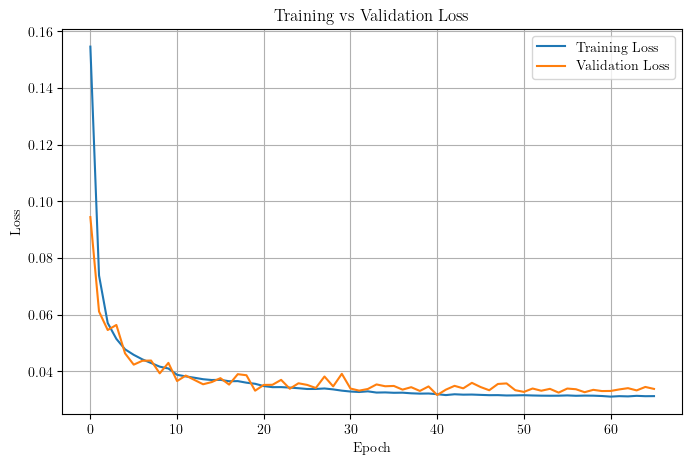

In [41]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
# plt.savefig("/net/CLUSTER/VAULT/users/mbatt/gravitational_lensing/plots/ViT_loss_3.png", dpi=300, bbox_inches="tight")
plt.show()


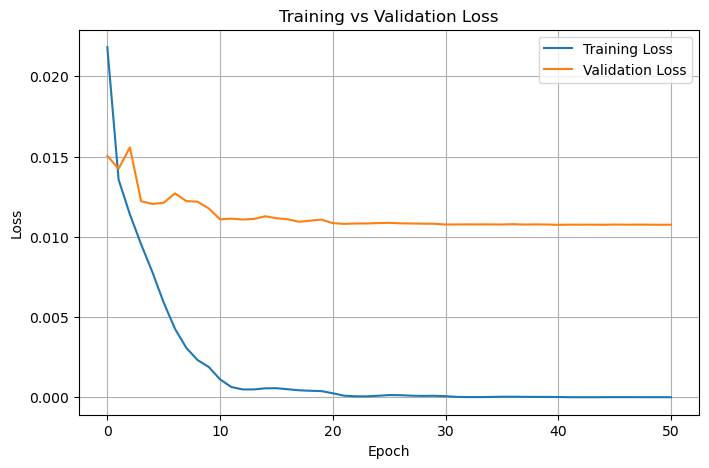

In [41]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
# plt.savefig("/net/CLUSTER/VAULT/users/mbatt/gravitational_lensing/plots/ViT_loss_3.png", dpi=300, bbox_inches="tight")
plt.show()


In [43]:
model.eval()
preds = []
targets = []

criterion = nn.MSELoss(reduction="none")

with torch.no_grad():
    for xb, yb in test_loader:   # <-- use test_loader here
        
        xb = xb.to(device)
        xb = xb[:,:-1,:,:]
        yb = yb.to(device)

        optimizer.zero_grad()

        # ---- Forward pass ----
        outputs = model(xb)

        preds.append(outputs.cpu())
        targets.append(yb.cpu())

# concatenate all batches
preds = torch.cat(preds)      # shape (N, 5)
targets = torch.cat(targets)  # shape (N, 5)

# compute per-parameter MSE
loss = criterion(preds, targets)   # shape (N, 5)
mse = loss.mean(dim=0)             # shape (5,)

print("Per-parameter MSE:", mse)

# --- Compute R2 per parameter ---
y_true_np = targets.numpy()
y_pred_np = preds.numpy()

r2_scores = []
for i in range(5):
    ss_res = np.sum((y_true_np[:, i] - y_pred_np[:, i])**2)
    ss_tot = np.sum((y_true_np[:, i] - np.mean(y_true_np[:, i]))**2)
    r2 = 1 - ss_res / ss_tot
    r2_scores.append(r2)

print("Per-parameter R2:", r2_scores)


Per-parameter MSE: tensor([0.0208, 0.0512, 0.0468, 0.0329, 0.0060])
Per-parameter R2: [0.7494208812713623, -0.9489802122116089, -0.795249342918396, -2.3875300884246826, 0.23350858688354492]


In [44]:
!nvidia-smi

Tue May 26 16:26:27 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 575.57.08              Driver Version: 575.57.08      CUDA Version: 12.9     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 2080 Ti     On  |   00000000:3B:00.0 Off |                  N/A |
| 33%   53C    P2            157W /  250W |    1479MiB /  11264MiB |     94%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [45]:
import matplotlib.pyplot as plt
import numpy as np

# Min/max used for normalization
df_min = df_sample[["r_Einstein", "gamma1", "gamma2", "ex", "ey"]].min().values
df_max = df_sample[["r_Einstein", "gamma1", "gamma2", "ex", "ey"]].max().values

# Convert to numpy
y_true = targets.numpy()
y_pred = preds.numpy()

# --- DENORMALIZATION ---
y_true_denorm = y_true * (df_max - df_min) + df_min
y_pred_denorm = y_pred * (df_max - df_min) + df_min

param_names = ["r_Einstein", "gamma1", "gamma2", "ex", "ey"]

plt.figure(figsize=(15, 8))
places = [(1,2), (5,6), (7,8), (9,10), (11,12)]

for i in range(5):

    # --- METRICS ---
    ss_res = np.sum((y_true_denorm[:, i] - y_pred_denorm[:, i])**2)
    ss_tot = np.sum((y_true_denorm[:, i] - np.mean(y_true_denorm[:, i]))**2)
    r2 = 1 - ss_res / ss_tot

    # Histogram comparison
    plt.subplot(3, 4, places[i][0])
    plt.hist(y_true_denorm[:, i], bins=30, alpha=0.6, label="Real")
    plt.hist(y_pred_denorm[:, i], bins=30, alpha=0.6, label="Predicted", edgecolor='black',linewidth=0.7)
    plt.title(f"{param_names[i]}")
    plt.legend()
    plt.grid(True)

    # Scatter plot real vs predicted
#     plt.subplot(5, 2, 2*i + 2)

    # Extract the variables
    x = y_true_denorm[:, i]
    y = y_pred_denorm[:, i]
    
    # Define number of bins
    nbins = 20

    # Compute bins
    bins = np.linspace(x.min(), x.max(), nbins + 1)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])

    medians = []
    sigmas = []

    for j in range(nbins):
        mask = (x >= bins[j]) & (x < bins[j+1])
        y_bin = y[mask]

        if len(y_bin) > 0:
            medians.append(np.median(y_bin))
            sigmas.append(np.std(y_bin))
        else:
            medians.append(np.nan)
            sigmas.append(np.nan)

    medians = np.array(medians)
    sigmas = np.array(sigmas)
    
    ax1 = plt.subplot(3, 4,  places[i][1])
    ax2 = ax1.twinx()

    # Plot median curve
    ax1.plot(bin_centers, medians, color="C0", lw=2, label="Median")
    ax1.set_ylabel("Predicted values")
    ax1.grid(True)

    # Plot ±1σ band
    ax1.fill_between(
        bin_centers,
        medians - sigmas,
        medians + sigmas,
        color="salmon",
        alpha=0.7,
        hatch="///",          # crosshatch style
        linewidth=0.0,        # avoid thick borders around the whole patch
        label="±1σ"
    )
    
    ax1.plot(bin_centers, medians - sigmas, color="black", linewidth=1.2)
    ax1.plot(bin_centers, medians + sigmas, color="black", linewidth=1.2)
    
    # 1:1 line
    min_val = min(x.min(), y.min())
    max_val = max(x.max(), y.max())
    ax1.plot([min_val, max_val], [min_val, max_val], "k--", lw=1.5)
    ax2.hist(y_true_denorm[:, i], bins=30, alpha=0.3)
    ax2.set_ylabel("Volume")
    
    ax1.set_xlabel("Real values")
    ax1.legend()
    plt.title(f"Real vs Predicted: {param_names[i]}")
#     plt.grid(True)
#     plt.legend()


plt.tight_layout()
plt.show()


RuntimeError: latex was not able to process the following string:
b'\\xb11\\u03c3'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error --output-directory=tmpbud2za2n 5fadb218a22983c92d196b53a8ff6257.tex

This is pdfTeX, Version 3.14159265-2.6-1.40.21 (TeX Live 2020) (preloaded format=latex)
 restricted \write18 enabled.
entering extended mode
(./5fadb218a22983c92d196b53a8ff6257.tex
LaTeX2e <2020-10-01> patch level 4
L3 programming layer <2021-02-18>
(/usr/share/texlive/texmf-dist/tex/latex/base/article.cls
Document Class: article 2020/04/10 v1.4m Standard LaTeX document class
(/usr/share/texlive/texmf-dist/tex/latex/base/size10.clo))
(/usr/share/texlive/texmf-dist/tex/latex/type1cm/type1cm.sty)
(/usr/share/texlive/texmf-dist/tex/latex/cm-super/type1ec.sty
(/usr/share/texlive/texmf-dist/tex/latex/base/t1cmr.fd))
(/usr/share/texlive/texmf-dist/tex/latex/base/inputenc.sty)
(/usr/share/texlive/texmf-dist/tex/latex/geometry/geometry.sty
(/usr

Error in callback <function _draw_all_if_interactive at 0x150fbc35d580> (for post_execute), with arguments args (),kwargs {}:


RuntimeError: latex was not able to process the following string:
b'\\xb11\\u03c3'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error --output-directory=tmp3ydjf2tm 5fadb218a22983c92d196b53a8ff6257.tex

This is pdfTeX, Version 3.14159265-2.6-1.40.21 (TeX Live 2020) (preloaded format=latex)
 restricted \write18 enabled.
entering extended mode
(./5fadb218a22983c92d196b53a8ff6257.tex
LaTeX2e <2020-10-01> patch level 4
L3 programming layer <2021-02-18>
(/usr/share/texlive/texmf-dist/tex/latex/base/article.cls
Document Class: article 2020/04/10 v1.4m Standard LaTeX document class
(/usr/share/texlive/texmf-dist/tex/latex/base/size10.clo))
(/usr/share/texlive/texmf-dist/tex/latex/type1cm/type1cm.sty)
(/usr/share/texlive/texmf-dist/tex/latex/cm-super/type1ec.sty
(/usr/share/texlive/texmf-dist/tex/latex/base/t1cmr.fd))
(/usr/share/texlive/texmf-dist/tex/latex/base/inputenc.sty)
(/usr/share/texlive/texmf-dist/tex/latex/geometry/geometry.sty
(/usr

RuntimeError: latex was not able to process the following string:
b'\\xb11\\u03c3'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error --output-directory=tmpc3avq694 5fadb218a22983c92d196b53a8ff6257.tex

This is pdfTeX, Version 3.14159265-2.6-1.40.21 (TeX Live 2020) (preloaded format=latex)
 restricted \write18 enabled.
entering extended mode
(./5fadb218a22983c92d196b53a8ff6257.tex
LaTeX2e <2020-10-01> patch level 4
L3 programming layer <2021-02-18>
(/usr/share/texlive/texmf-dist/tex/latex/base/article.cls
Document Class: article 2020/04/10 v1.4m Standard LaTeX document class
(/usr/share/texlive/texmf-dist/tex/latex/base/size10.clo))
(/usr/share/texlive/texmf-dist/tex/latex/type1cm/type1cm.sty)
(/usr/share/texlive/texmf-dist/tex/latex/cm-super/type1ec.sty
(/usr/share/texlive/texmf-dist/tex/latex/base/t1cmr.fd))
(/usr/share/texlive/texmf-dist/tex/latex/base/inputenc.sty)
(/usr/share/texlive/texmf-dist/tex/latex/geometry/geometry.sty
(/usr

<Figure size 1500x800 with 15 Axes>

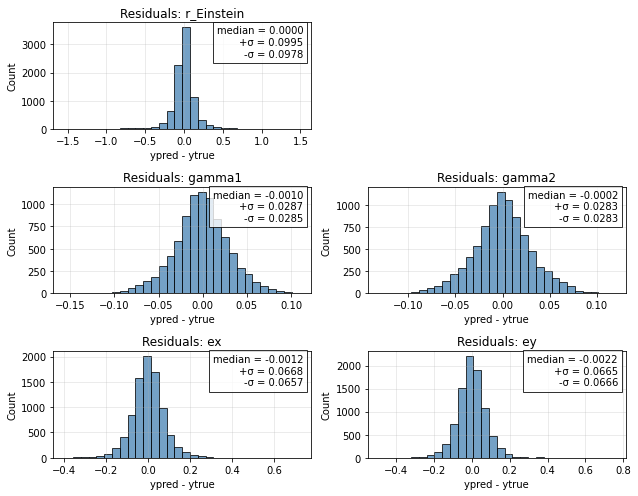

In [71]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# --- Min/max used for normalization ---
df_min = df_sample[["r_Einstein", "gamma1", "gamma2", "ex", "ey"]].min().values
df_max = df_sample[["r_Einstein", "gamma1", "gamma2", "ex", "ey"]].max().values
scale = df_max - df_min   # range for each parameter

# --- Convert to numpy ---
y_true = targets.numpy()
y_pred = preds.numpy()

# --- DENORMALIZATION ---
y_true_denorm = y_true * scale + df_min
y_pred_denorm = y_pred * scale + df_min

# --- Compute denormalised errors ---
error_denorm = y_pred_denorm - y_true_denorm

# --- Asymmetric statistics ---
medians = np.median(error_denorm, axis=0)
p16 = np.percentile(error_denorm, 16, axis=0)
p84 = np.percentile(error_denorm, 84, axis=0)

sigma_minus = medians - p16
sigma_plus  = p84 - medians

param_names = ["r_Einstein", "gamma1", "gamma2", "ex", "ey"]

# --- Plot ---
fig, axes = plt.subplots(3, 2, figsize=(9, 7))
axes = axes.flatten()  
poss = [1,3,4,5,6]

for i in range(error_denorm.shape[1]):
    plt.subplot(3, 2, poss[i])
    plt.hist(error_denorm[:, i], bins=30, alpha=0.75,
             color="steelblue", edgecolor="black")
    plt.title(f"Residuals: {param_names[i]}")
    plt.xlabel("ypred - ytrue")
    plt.ylabel("Count")
    plt.grid(alpha=0.3)

    # --- Add text box with denormalised stats ---
    text = (
        f"median = {medians[i]:.4f}\n"
        f"+σ = {sigma_plus[i]:.4f}\n"
        f"-σ = {sigma_minus[i]:.4f}"
    )

    plt.text(
        0.97, 0.97, text,
        transform=plt.gca().transAxes,
        fontsize=10,
        ha="right", va="top",
        bbox=dict(facecolor="white", alpha=0.8, edgecolor="black")
    )

plt.tight_layout()
axes[1].axis("off")
# plt.savefig("/net/CLUSTER/VAULT/users/mbatt/gravitational_lensing/plots/resnet_residus_sqrt_images_first.png", dpi=300, bbox_inches="tight")
plt.show()

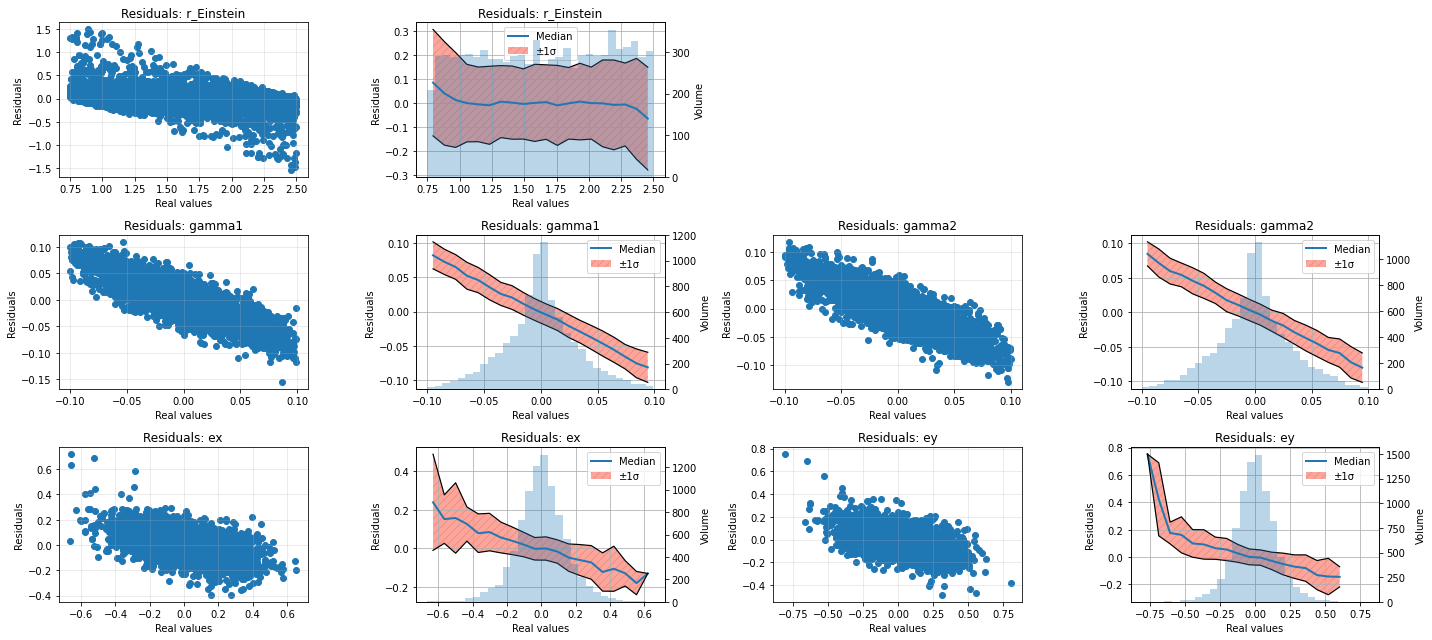

In [40]:
# import matplotlib.pyplot as plt
# import numpy as np

# # Min/max used for normalization
# df_min = df_sample[["r_Einstein", "gamma1", "gamma2", "ex", "ey"]].min().values
# df_max = df_sample[["r_Einstein", "gamma1", "gamma2", "ex", "ey"]].max().values

# # Convert to numpy
# y_true = targets.numpy()
# y_pred = preds.numpy()

# # --- DENORMALIZATION ---
# y_true_denorm = y_true * (df_max - df_min) + df_min
# y_pred_denorm = y_pred * (df_max - df_min) + df_min
# error_denorm = y_pred_denorm - y_true_denorm

# param_names = ["r_Einstein", "gamma1", "gamma2", "ex", "ey"]

# plt.figure(figsize=(20, 9))
# places = [(1,2), (5,6), (7,8), (9,10), (11,12)]

# for i in range(5):
#     plt.subplot(3, 4, places[i][0])
#     plt.scatter(y_true_denorm[:,i], error_denorm[:,i])
#     plt.title(f"Residuals: {param_names[i]}")
#     plt.xlabel("Real values")
#     plt.ylabel("Residuals")
#     plt.grid(alpha=0.3)
    
#     # Extract the variables
#     x = y_true_denorm[:, i]
#     y = error_denorm[:, i]
    
#     # Define number of bins
#     nbins = 20

#     # Compute bins
#     bins = np.linspace(x.min(), x.max(), nbins + 1)
#     bin_centers = 0.5 * (bins[:-1] + bins[1:])

#     medians = []
#     sigmas = []

#     for j in range(nbins):
#         mask = (x >= bins[j]) & (x < bins[j+1])
#         y_bin = y[mask]

#         if len(y_bin) > 0:
#             medians.append(np.median(y_bin))
#             sigmas.append(np.std(y_bin))
#         else:
#             medians.append(np.nan)
#             sigmas.append(np.nan)

#     medians = np.array(medians)
#     sigmas = np.array(sigmas)
    
#     ax1 = plt.subplot(3, 4,  places[i][1])
#     ax2 = ax1.twinx()

#     # Plot median curve
#     ax1.plot(bin_centers, medians, color="C0", lw=2, label="Median")
#     ax1.set_ylabel("Residuals")
#     ax1.grid(True)

#     # Plot ±1σ band
#     ax1.fill_between(
#         bin_centers,
#         medians - sigmas,
#         medians + sigmas,
#         color="salmon",
#         alpha=0.7,
#         hatch="///",          # crosshatch style
#         linewidth=0.0,        # avoid thick borders around the whole patch
#         label="±1σ"
#     )
    
#     ax1.plot(bin_centers, medians - sigmas, color="black", linewidth=1.2)
#     ax1.plot(bin_centers, medians + sigmas, color="black", linewidth=1.2)
#     ax2.hist(y_true_denorm[:, i], bins=30, alpha=0.3)
#     ax2.set_ylabel("Volume")
    
#     ax1.set_xlabel("Real values")
#     ax1.legend()
#     plt.title(f"Residuals: {param_names[i]}")

# plt.tight_layout()
# # plt.savefig("/net/CLUSTER/VAULT/users/mbatt/gravitational_lensing/plots/resnet_residuals_vs_true_sqrt_13.png", dpi=300, bbox_inches="tight")
# plt.show()
